In [1]:
# Google Colab setup for: LTV, Retention & Marketing ROI Modelling
# Dataset: Online Retail II (UCI / Kaggle)
# -------------------------------------------------

# Runtime info & optional GPU
from IPython.display import HTML, display
import sys, os, platform
print('Python', sys.version)
print('Platform:', platform.platform())
try:
    import torch
    print('PyTorch available — CUDA:', torch.cuda.is_available())
except Exception:
    pass

Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
PyTorch available — CUDA: False


In [2]:
# Install dependencies
# The main packages we will use: pandas, numpy, matplotlib, seaborn, lifetimes, scikit-learn, openpyxl (for xlsx), plotly, streamlit (optional), kaggle (optional)
# Run this cell if packages are missing. Colab already has many preinstalled.
!pip install --quiet pandas numpy matplotlib seaborn plotly scikit-learn lifetimes openpyxl kaggle xlrd



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 7.4 MB/s eta 0:00:00


In [3]:
import kagglehub
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.


In [4]:
#Imports & constants
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.options.display.max_columns = 200
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [5]:
import pandas as pd

df = pd.read_csv(f"{path}/online_retail_II.csv")
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 1. Data Cleaning & Exploratory Data Analysis

In [7]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px




In [8]:
pd.options.display.max_columns = 200
sns.set(style='whitegrid')

In [9]:
print("Initial shape:", df.shape)

Initial shape: (1067371, 8)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


Notice Invoice Date and Invoice Number are object type.

In [11]:
# Different Kaggle mirrors may use Invoice / InvoiceNo / Quantity / UnitPrice / Price
cols = {c.lower(): c for c in df.columns}
print("Columns detected:", df.columns.tolist())


# Rename common variants
rename_map = {}
for col in df.columns:
  cl = col.lower()
  if cl in ['invoice', 'invoiceno', 'invoice_no']:
    rename_map[col] = 'InvoiceNo'
  if cl in ['quantity', 'qty']:
    rename_map[col] = 'Quantity'
  if cl in ['unitprice', 'price', 'unit_price']:
    rename_map[col] = 'UnitPrice'
  if cl in ['invoicedate', 'date', 'invoice_date']:
    rename_map[col] = 'InvoiceDate'
  if cl in ['customerid', 'customer_id']:
    rename_map[col] = 'CustomerID'

if rename_map:
  df.rename(columns=rename_map, inplace=True)

print("Standardized columns:", df.columns.tolist())

Columns detected: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Standardized columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'Customer ID', 'Country']


In [12]:
df.describe()

,Quantity,UnitPrice,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


First we fix the Invoice Date Column and sort the data according to it.

In [13]:
# Convert date column & sort chronologically
if 'InvoiceDate' in df.columns:
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df.sort_values('InvoiceDate')

print("Date range:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())

Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [15]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


Now we can see Quanity and Unit Price have some unexpected minimum and maximum values. So let us visualize the graphs

In [17]:
import matplotlib.pyplot as plt

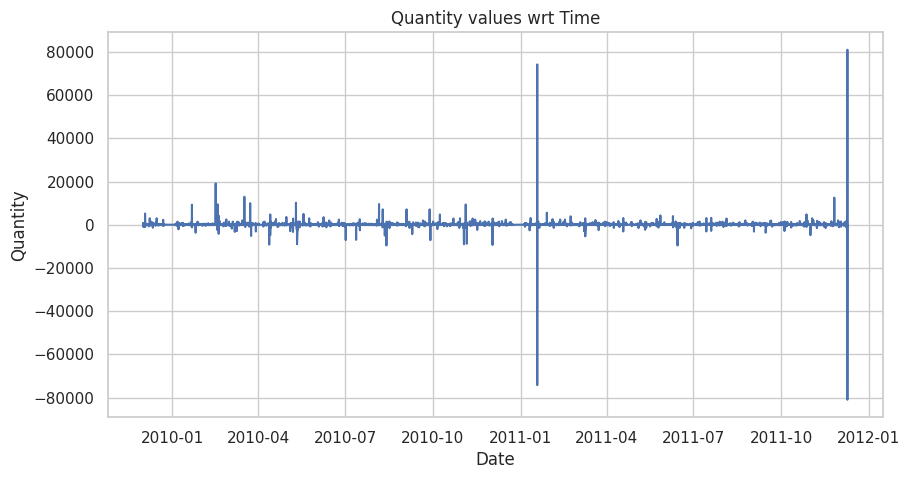

In [18]:
#Quantity Graph
plt.figure(figsize=(10,5))
plt.plot(df['InvoiceDate'],df['Quantity'],)
plt.title('Quantity values wrt Time')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.show()

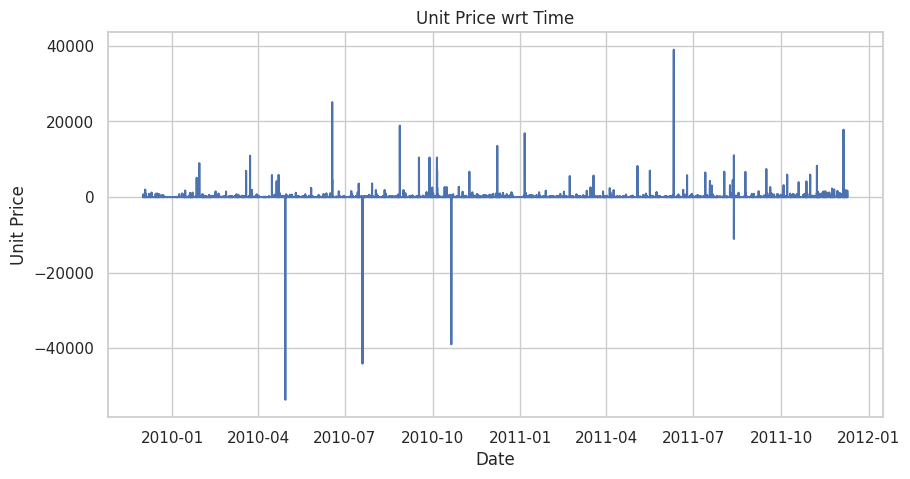

In [19]:
#Unit Price Graph
plt.figure(figsize=(10,5))
plt.plot(df['InvoiceDate'],df['UnitPrice'],)
plt.title('Unit Price wrt Time')
plt.xlabel('Date')
plt.ylabel('Unit Price')
plt.show()

We will omit these rows as they are not large in number

In [20]:
#Remove negative or zero Quantity/Price
before = len(df)
if 'Quantity' in df.columns:
  df = df[df['Quantity'] > 0]
  df = df[df['Quantity'] < 20000]
if 'UnitPrice' in df.columns:
  df = df[df['UnitPrice'] > 0]
  df = df[df['UnitPrice'] < 20000]
print(f"Removed invalid rows (<=0 and >2000 values): {before - len(df)}")

Removed invalid rows (<=0 and >2000 values): 25703


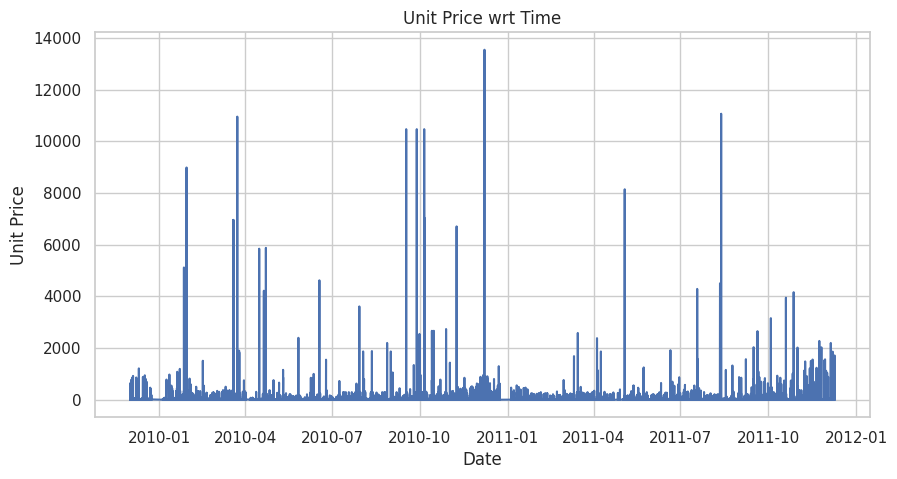

In [21]:
#Unit Price Graph
plt.figure(figsize=(10,5))
plt.plot(df['InvoiceDate'],df['UnitPrice'],)
plt.title('Unit Price wrt Time')
plt.xlabel('Date')
plt.ylabel('Unit Price')
plt.show()

In [22]:
# Count cancelled transactions
cancelled_count = df[df['InvoiceNo'].astype(str).str.startswith('C')].shape[0]

cancelled_count
print(f"Total cancelled transactions: {cancelled_count}")


Total cancelled transactions: 1


In [23]:
# Remove cancellations
# Cancellations typically have InvoiceNo starting with 'C'
if 'InvoiceNo' in df.columns:
  before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Removed cancellations: {before - len(df)} rows")

Removed cancellations: 1 rows


In [24]:
#  Top-level metrics
n_customers = df['Customer ID'].nunique() if 'Customer ID' in df.columns else None
n_orders = df['InvoiceNo'].nunique() if 'InvoiceNo' in df.columns else None

print("Total rows:", len(df))
print("Unique customers:", n_customers)
print("Unique orders:", n_orders)

Total rows: 1041667
Unique customers: 5878
Unique orders: 40074


In [25]:
#  Add order_value
if 'Quantity' in df.columns and 'UnitPrice' in df.columns:
  df['Order_value'] = df['Quantity'] * df['UnitPrice']

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1041667 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1041667 non-null  object        
 1   StockCode    1041667 non-null  object        
 2   Description  1041667 non-null  object        
 3   Quantity     1041667 non-null  int64         
 4   InvoiceDate  1041667 non-null  datetime64[ns]
 5   UnitPrice    1041667 non-null  float64       
 6   Customer ID  805547 non-null   float64       
 7   Country      1041667 non-null  object        
 8   Order_value  1041667 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 79.5+ MB


In [27]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,Customer ID,Order_value
count,1.041667e+06,1041667,1.041667e+06,805547.000000,1.041667e+06
mean,1.081449e+01,2011-01-03 16:31:41.490591744,4.052585e+00,15331.957294,1.987375e+01
min,1.000000e+00,2009-12-01 07:45:00,1.000000e-03,12346.000000,1.000000e-03
25%,1.000000e+00,2010-07-12 10:31:30,1.250000e+00,13982.000000,3.900000e+00
50%,3.000000e+00,2010-12-07 15:33:00,2.100000e+00,15271.000000,9.960000e+00
75%,1.000000e+01,2011-07-24 12:05:00,4.130000e+00,16805.000000,1.770000e+01
max,1.915200e+04,2011-12-09 12:50:00,1.354133e+04,18287.000000,3.897000e+04
std,6.651310e+01,NaN,4.518548e+01,1696.735430,8.772516e+01


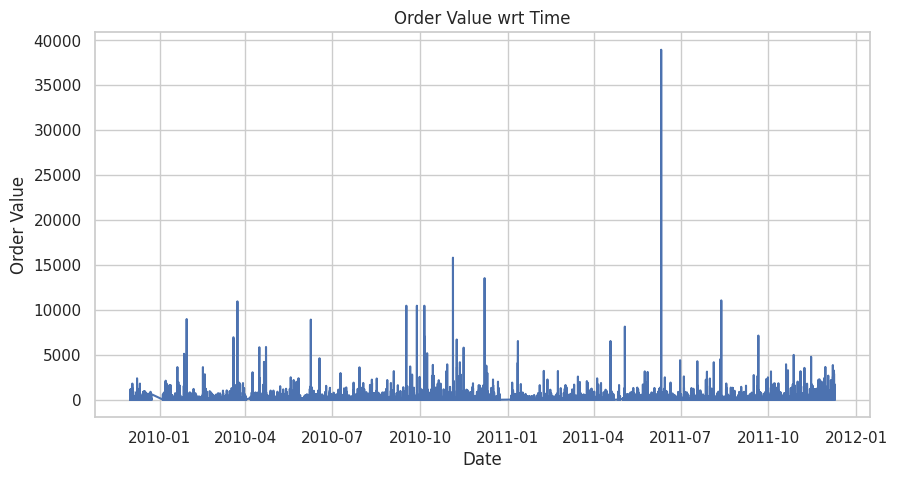

In [29]:
# Distribution of order values
plt.figure(figsize=(10,5))
plt.plot(df['InvoiceDate'],df['Order_value'],)
plt.title('Order Value wrt Time')
plt.xlabel('Date')
plt.ylabel('Order Value')
plt.show()

In [37]:
if 'Order_value' in df.columns:
  df = df[df['Order_value'] < 6000]

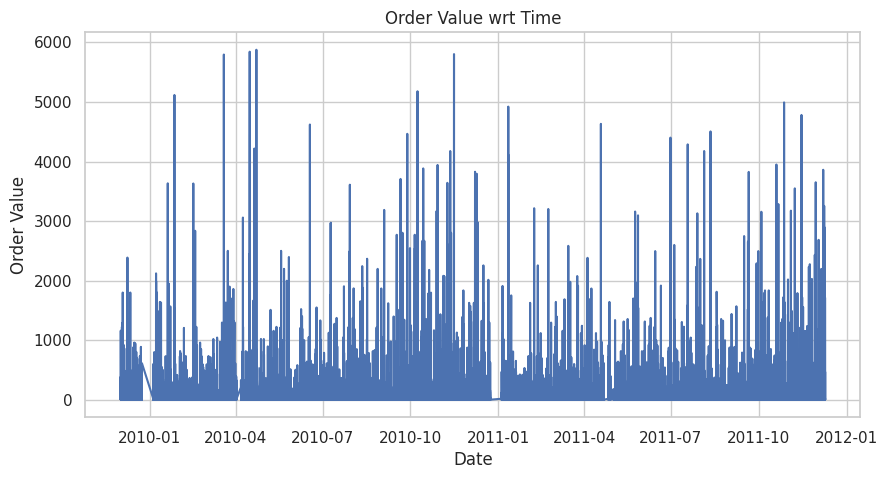

In [38]:
# Distribution of order values
plt.figure(figsize=(10,5))
plt.plot(df['InvoiceDate'],df['Order_value'],)
plt.title('Order Value wrt Time')
plt.xlabel('Date')
plt.ylabel('Order Value')
plt.show()

In [41]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,Customer ID,Order_value
count,1.041647e+06,1041647,1.041647e+06,805535.000000,1.041647e+06
mean,1.079494e+01,2011-01-03 16:33:36.578994688,3.921220e+00,15331.949364,1.966274e+01
min,1.000000e+00,2009-12-01 07:45:00,1.000000e-03,12346.000000,1.000000e-03
25%,1.000000e+00,2010-07-12 10:37:00,1.250000e+00,13982.000000,3.900000e+00
50%,3.000000e+00,2010-12-07 15:33:00,2.100000e+00,15271.000000,9.960000e+00
75%,1.000000e+01,2011-07-24 12:05:00,4.130000e+00,16805.000000,1.770000e+01
max,1.915200e+04,2011-12-09 12:50:00,5.876340e+03,18287.000000,5.876340e+03
std,6.563611e+01,NaN,2.649340e+01,1696.738028,6.676785e+01


In [44]:
#Monthly revenue trend
df['Year_month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
monthly_rev = df.groupby('Year_month')['Order_value'].sum().reset_index()
px.line(monthly_rev, x='Year_month', y='Order_value', title='Monthly Revenue Trend')

/tmp/ipython-input-2354104394.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['InvoiceDate'].dt.to_period('M').astype(str)


In [49]:
# Top 10 products by revenue
if 'Description' in df.columns:
  top_products = df.groupby('Description')['Order_value'].sum().nlargest(10).reset_index()
  fig = px.bar(top_products, x='Order_value', y='Description', orientation='h', title='Top 10 Products by Revenue')
  fig.show()

In [50]:
customer_summary = df.groupby('Customer ID').agg(
total_spend=('Order_value','sum'),
num_orders=('InvoiceNo','nunique'),
first_purchase=('InvoiceDate','min'),
last_purchase=('InvoiceDate','max')
).reset_index()


customer_summary['recency'] = (df['InvoiceDate'].max() - customer_summary['last_purchase']).dt.days
#The number of days between the customer’s last purchase and the most recent date in the whole dataset.
customer_summary['frequency'] = customer_summary['num_orders']
customer_summary['monetary'] = customer_summary['total_spend']


customer_summary.head()

,Customer ID,total_spend,num_orders,first_purchase,last_purchase,recency,frequency,monetary
0,12346.0,372.86,11,2009-12-14 08:34:00,2010-06-28 13:53:00,528,11,372.86
1,12347.0,5633.32,8,2010-10-31 14:20:00,2011-12-07 15:52:00,1,8,5633.32
2,12348.0,2019.40,5,2010-09-27 14:59:00,2011-09-25 13:13:00,74,5,2019.40
3,12349.0,4428.69,4,2010-04-29 13:20:00,2011-11-21 09:51:00,18,4,4428.69
4,12350.0,334.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00,309,1,334.40


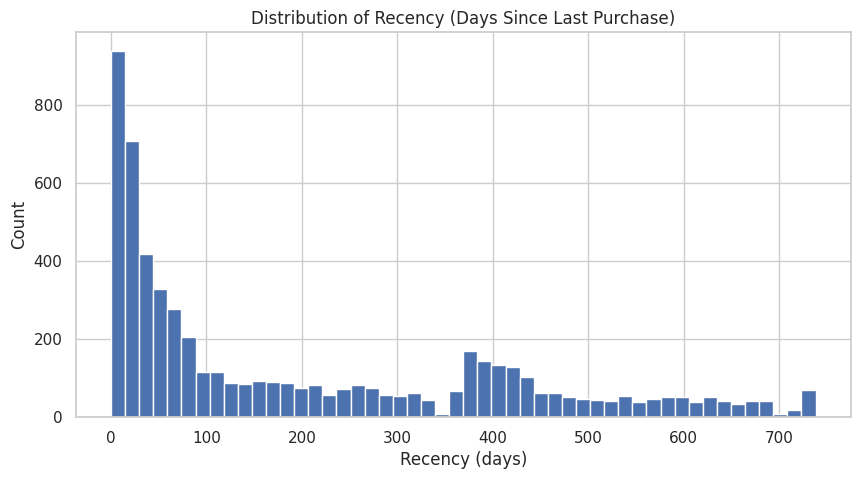

In [51]:
# Recency distribution
plt.figure(figsize=(10,5))
plt.hist(customer_summary['recency'], bins=50)
plt.title("Distribution of Recency (Days Since Last Purchase)")
plt.xlabel("Recency (days)")
plt.ylabel("Count")
plt.show()

In [52]:
# Quantity vs Description (Top 20)
if 'Description' in df.columns:
  qty_desc = df.groupby('Description')['Quantity'].sum().nlargest(20).reset_index()
  fig = px.bar(qty_desc, x='Quantity', y='Description', orientation='h', title='Top 20 Products by Quantity')
  fig.show()

In [54]:
#  Price vs Description (Top 20 by UnitPrice * Quantity)
if 'Description' in df.columns:
  price_desc = df.groupby('Description')['Order_value'].sum().nlargest(20).reset_index()
  fig = px.bar(price_desc, x='Order_value', y='Description', orientation='h', title='Top 20 Products by Revenue')
  fig.show()

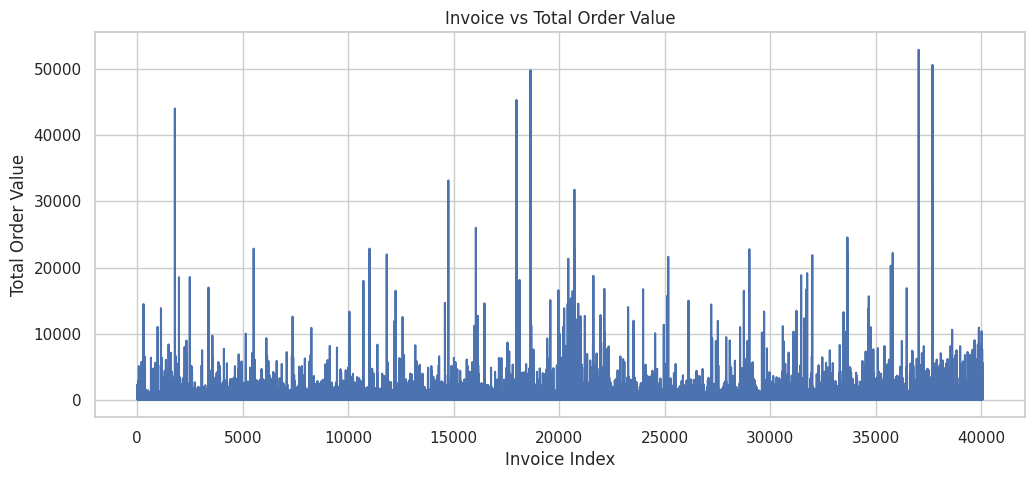

In [56]:
# Invoice vs Price (Average order value per invoice)
inv_price = df.groupby('InvoiceNo')['Order_value'].sum().reset_index()
plt.figure(figsize=(12,5))
plt.plot(inv_price['Order_value'].values)
plt.title('Invoice vs Total Order Value')
plt.xlabel('Invoice Index')
plt.ylabel('Total Order Value')
plt.show()

In [57]:
#  Save cleaned dataset
clean_path = "clean_online_retail.csv"
df.to_csv(clean_path, index=False)
print(f"Saved cleaned dataset to {clean_path}")

Saved cleaned dataset to clean_online_retail.csv


In [ ]:
#from google.colab import files
#files.download(clean_path)

# 2. Cohort Retention

1. Count how many cohort customers bought in each month since their first purchase.

2. Pivot this into a matrix where rows are cohorts and columns are months since acquisition.

3. Used to calculate retention and churn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load cleaned data
df = pd.read_csv("/content/clean_online_retail.csv", parse_dates=["InvoiceDate"])

## Creating Invoice Month & Cohort Month

In [3]:
# Invoice month
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Cohort month: first purchase month of each customer
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceMonth'].transform('min')


In [4]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,Customer ID,Order_value
count,1041647.00,1041647.00,1041647,1041647.00,805535.00,1041647.00
mean,537656.04,10.79,2011-01-03 16:33:36.578994688,3.92,15331.95,19.66
min,489434.00,1.00,2009-12-01 07:45:00,0.00,12346.00,0.00
25%,515348.00,1.00,2010-07-12 10:37:00,1.25,13982.00,3.90
50%,537642.00,3.00,2010-12-07 15:33:00,2.10,15271.00,9.96
75%,561040.00,10.00,2011-07-24 12:05:00,4.13,16805.00,17.70
max,581587.00,19152.00,2011-12-09 12:50:00,5876.34,18287.00,5876.34
std,26659.38,65.64,NaN,26.49,1696.74,66.77


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041647 entries, 0 to 1041646
Data columns (total 12 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   InvoiceNo     1041647 non-null  int64         
 1   StockCode     1041647 non-null  object        
 2   Description   1041647 non-null  object        
 3   Quantity      1041647 non-null  int64         
 4   InvoiceDate   1041647 non-null  datetime64[ns]
 5   UnitPrice     1041647 non-null  float64       
 6   Customer ID   805535 non-null   float64       
 7   Country       1041647 non-null  object        
 8   Order_value   1041647 non-null  float64       
 9   year_month    1041647 non-null  object        
 10  InvoiceMonth  1041647 non-null  period[M]     
 11  CohortMonth   805535 non-null   period[M]     
dtypes: datetime64[ns](1), float64(3), int64(2), object(4), period[M](2)
memory usage: 95.4+ MB


In [6]:
df_cohort = df.dropna(subset=['Customer ID']).copy()

For each transaction, we calculate the number of months since that cohort started. This is the cohort_index.

In [7]:
def get_month_diff(end, start):
    return (end.year - start.year) * 12 + (end.month - start.month)

df_cohort['CohortIndex'] = df_cohort.apply(
    lambda row: get_month_diff(row['InvoiceMonth'].to_timestamp(),
                               row['CohortMonth'].to_timestamp()) + 1,axis=1)


In [8]:
df_cohort['CohortIndex'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25])

### Building Cohort Table (# of Active Customers)

For each (CohortMonth, CohortIndex) pair, I counted unique customers who purchased in that period.

In [9]:
#Group customers by Cohort + CohortIndex
cohort_data = df_cohort.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

cohort_data


,CohortMonth,CohortIndex,Customer ID
0,2009-12,1,955
1,2009-12,2,337
2,2009-12,3,319
3,2009-12,4,406
4,2009-12,5,363
...,...,...,...
320,2011-10,2,71
321,2011-10,3,35
322,2011-11,1,191
323,2011-11,2,27


*   Rows = cohort months
*   Columns = months since acquisition
*   Cells = Number of customers who bought in that month







In [10]:
#Turning the table into a retention matrix
cohort_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

cohort_pivot

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,955.00,337.00,319.00,406.00,363.00,343.00,360.00,327.00,321.00,346.00,...,289.00,251.00,289.00,270.00,248.00,244.00,301.00,291.00,389.00,188.00
2010-01,383.00,79.00,119.00,117.00,101.00,115.00,99.00,88.00,107.00,122.00,...,58.00,90.00,76.00,71.00,75.00,93.00,74.00,94.00,22.00,NaN
2010-02,374.00,89.00,84.00,109.00,92.00,75.00,72.00,107.00,95.00,103.00,...,75.00,60.00,61.00,54.00,86.00,86.00,61.00,22.00,NaN,NaN
2010-03,441.00,84.00,102.00,107.00,103.00,90.00,109.00,134.00,122.00,48.00,...,75.00,77.00,69.00,78.00,89.00,94.00,35.00,NaN,NaN,NaN
2010-04,294.00,57.00,57.00,48.00,54.00,66.00,81.00,77.00,31.00,32.00,...,46.00,41.00,44.00,53.00,66.00,17.00,NaN,NaN,NaN,NaN
2010-05,254.00,40.00,43.00,44.00,45.00,65.00,54.00,32.00,15.00,21.00,...,32.00,35.00,42.00,39.00,12.00,NaN,NaN,NaN,NaN,NaN
2010-06,270.00,47.00,51.00,55.00,62.00,77.00,34.00,24.00,22.00,32.00,...,33.00,36.00,55.00,14.00,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.00,29.00,34.00,55.00,54.00,26.00,21.00,27.00,27.00,21.00,...,32.00,44.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.00,33.00,48.00,52.00,28.00,19.00,16.00,20.00,22.00,21.00,...,32.00,11.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Everything beyond the triangle = NaN, because those months do not exist.

### Retention Matrix

*   Rows = cohort months
*   Columns = months since acquisition
*   Cells = retention rate (%) [Dividing each row by column 0 value, gives retention %]







In [70]:
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0).round(3)
retention


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,1.00,0.35,0.33,0.42,0.38,0.36,0.38,0.34,0.34,0.36,0.42,0.49,0.38,0.28,0.24,0.30,0.26,0.30,0.28,0.26,0.26,0.32,0.30,0.41,0.20
2010-01,1.00,0.21,0.31,0.30,0.26,0.30,0.26,0.23,0.28,0.32,0.30,0.17,0.22,0.18,0.19,0.15,0.23,0.20,0.18,0.20,0.24,0.19,0.24,0.06,NaN
2010-02,1.00,0.24,0.23,0.29,0.25,0.20,0.19,0.29,0.25,0.28,0.12,0.13,0.15,0.17,0.12,0.20,0.16,0.16,0.14,0.23,0.23,0.16,0.06,NaN,NaN
2010-03,1.00,0.19,0.23,0.24,0.23,0.20,0.25,0.30,0.28,0.11,0.12,0.14,0.20,0.16,0.20,0.17,0.17,0.16,0.18,0.20,0.21,0.08,NaN,NaN,NaN
2010-04,1.00,0.19,0.19,0.16,0.18,0.22,0.28,0.26,0.10,0.11,0.07,0.14,0.14,0.16,0.16,0.16,0.14,0.15,0.18,0.22,0.06,NaN,NaN,NaN,NaN
2010-05,1.00,0.16,0.17,0.17,0.18,0.26,0.21,0.13,0.06,0.08,0.11,0.13,0.15,0.15,0.10,0.13,0.14,0.17,0.15,0.05,NaN,NaN,NaN,NaN,NaN
2010-06,1.00,0.17,0.19,0.20,0.23,0.28,0.13,0.09,0.08,0.12,0.11,0.14,0.15,0.12,0.11,0.12,0.13,0.20,0.05,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.00,0.16,0.18,0.30,0.29,0.14,0.11,0.14,0.14,0.11,0.13,0.14,0.13,0.13,0.19,0.17,0.24,0.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.00,0.20,0.30,0.32,0.17,0.12,0.10,0.12,0.14,0.13,0.13,0.12,0.15,0.18,0.18,0.20,0.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Plotting Retention Heatmap

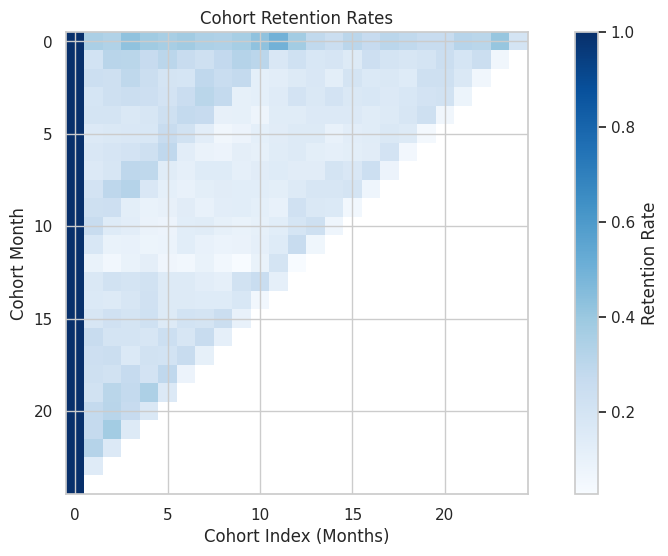

In [71]:
plt.figure(figsize=(12, 6))
plt.imshow(retention, cmap="Blues")
plt.title("Cohort Retention Rates")
plt.xlabel("Cohort Index (Months)")
plt.ylabel("Cohort Month")
plt.colorbar(label="Retention Rate")
plt.show()


Seaborn gracefully ignores NaNs and leaves them white.

### Churn Matrix

In [72]:
churn = 1 - retention
churn


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,0.00,0.65,0.67,0.57,0.62,0.64,0.62,0.66,0.66,0.64,0.58,0.51,0.62,0.72,0.76,0.70,0.74,0.70,0.72,0.74,0.74,0.69,0.70,0.59,0.80
2010-01,0.00,0.79,0.69,0.70,0.74,0.70,0.74,0.77,0.72,0.68,0.70,0.83,0.78,0.82,0.81,0.85,0.77,0.80,0.81,0.80,0.76,0.81,0.76,0.94,NaN
2010-02,0.00,0.76,0.78,0.71,0.75,0.80,0.81,0.71,0.75,0.72,0.89,0.87,0.85,0.83,0.88,0.80,0.84,0.84,0.86,0.77,0.77,0.84,0.94,NaN,NaN
2010-03,0.00,0.81,0.77,0.76,0.77,0.80,0.75,0.70,0.72,0.89,0.88,0.86,0.80,0.84,0.80,0.83,0.82,0.84,0.82,0.80,0.79,0.92,NaN,NaN,NaN
2010-04,0.00,0.81,0.81,0.84,0.82,0.78,0.72,0.74,0.90,0.89,0.93,0.86,0.86,0.84,0.84,0.84,0.86,0.85,0.82,0.78,0.94,NaN,NaN,NaN,NaN
2010-05,0.00,0.84,0.83,0.83,0.82,0.74,0.79,0.87,0.94,0.92,0.89,0.87,0.85,0.85,0.90,0.87,0.86,0.83,0.85,0.95,NaN,NaN,NaN,NaN,NaN
2010-06,0.00,0.83,0.81,0.80,0.77,0.72,0.87,0.91,0.92,0.88,0.89,0.86,0.85,0.88,0.89,0.88,0.87,0.80,0.95,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,0.00,0.84,0.82,0.70,0.71,0.86,0.89,0.85,0.85,0.89,0.87,0.85,0.87,0.87,0.81,0.83,0.76,0.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,0.00,0.80,0.70,0.68,0.83,0.88,0.90,0.88,0.86,0.87,0.87,0.88,0.85,0.81,0.82,0.80,0.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Churn Curves

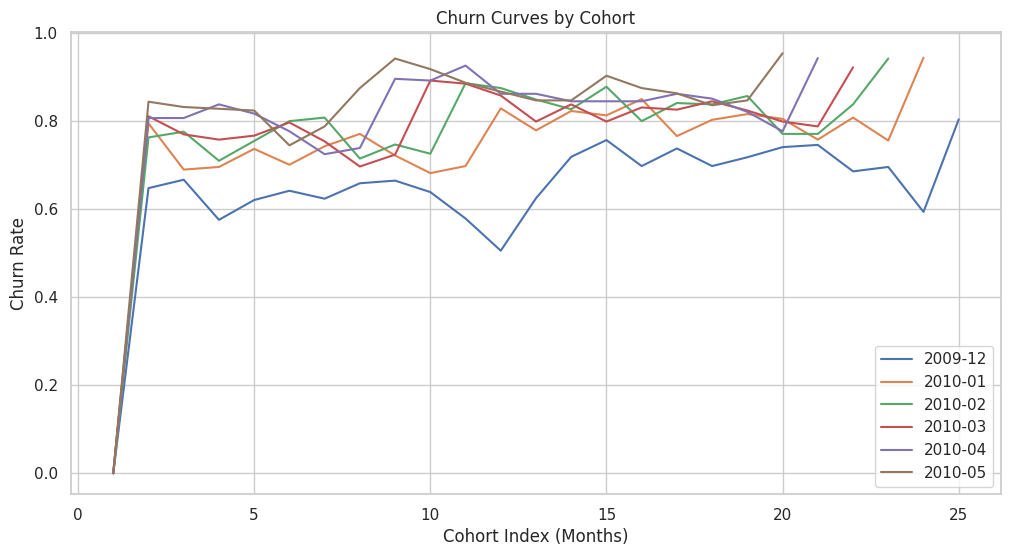

In [73]:
plt.figure(figsize=(12,6))

for cohort in churn.index[:6]:
    plt.plot(churn.columns, churn.loc[cohort], label=str(cohort))

plt.legend()
plt.title("Churn Curves by Cohort")
plt.xlabel("Cohort Index (Months)")
plt.ylabel("Churn Rate")
plt.show()


### Summarising Stats

In [74]:
print("Average Retention Month 2:", retention[2].mean())
print("Average Retention Month 3:", retention[3].mean())
print("Average Churn Month 2:", churn[2].mean())


Average Retention Month 2: 0.21158333333333335
Average Retention Month 3: 0.21926086956521737
Average Churn Month 2: 0.7884166666666667


# 3. RFM (Recency,Frequnecy,Monetary) Segmentation

1. Recency (R) : “How recently did the customer make a purchase?”
* Lower recency = more recent = better customer.
2. Frequency (F) : “How many times has the customer purchased?”
* Higher frequency = more engaged customer.
3. Monetary (M) : “How much money has the customer spent in total?”
* Higher monetary value = more valuable customer.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [12]:
# Load cleaned dataset (from 01_EDA output)
df = pd.read_csv("/content/clean_online_retail.csv", parse_dates=["InvoiceDate"])


### RFM Table

In [13]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [14]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'Order_value': 'sum'                                      # Monetary
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
rfm.head()


,Customer ID,Recency,Frequency,Monetary
0,12346.00,529,11,372.86
1,12347.00,2,8,5633.32
2,12348.00,75,5,2019.40
3,12349.00,19,4,4428.69
4,12350.00,310,1,334.40


### RFM Scoring using Quantiles

In [15]:
# Helper function
def rfm_score(x, q_dict):
    if x <= q_dict[0.25]:
        return 4
    elif x <= q_dict[0.50]:
        return 3
    elif x <= q_dict[0.75]:
        return 2
    else:
        return 1


In [16]:
quantiles = rfm[['Recency','Frequency','Monetary']].quantile([0.25,0.5,0.75]).to_dict()
quantiles


{'Recency': {0.25: 26.0, 0.5: 96.0, 0.75: 380.0},
 'Frequency': {0.25: 1.0, 0.5: 3.0, 0.75: 7.0},
 'Monetary': {0.25: 348.3925, 0.5: 896.63, 0.75: 2300.7675}}

In [17]:
rfm['R_score'] = rfm['Recency'].apply(lambda x: rfm_score(x, quantiles['Recency']))
rfm['F_score'] = rfm['Frequency'].apply(lambda x: rfm_score(x, quantiles['Frequency']))
rfm['M_score'] = rfm['Monetary'].apply(lambda x: rfm_score(x, quantiles['Monetary']))

# Combined RFM score as a string
rfm['RFM'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head()


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM
0,12346.00,529,11,372.86,1,1,3,113
1,12347.00,2,8,5633.32,4,1,1,411
2,12348.00,75,5,2019.40,3,2,2,322
3,12349.00,19,4,4428.69,4,2,1,421
4,12350.00,310,1,334.40,2,4,4,244


### Assign RFM Segments (Business Rules)

In [18]:
def rfm_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']

    if r == 4 and f == 4 and m == 4:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal Customers"
    if r == 4 and f <= 2:
        return "New Customers"
    if r == 2 and f >= 3:
        return "Potential Loyalist"
    if f == 1 and m == 1:
        return "At Risk"
    return "Others"

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)
rfm['Segment'].value_counts()


,count
Segment,
Others,2371
New Customers,1103
Loyal Customers,968
Potential Loyalist,899
At Risk,456
Champions,79


### Plot RFM Distribution

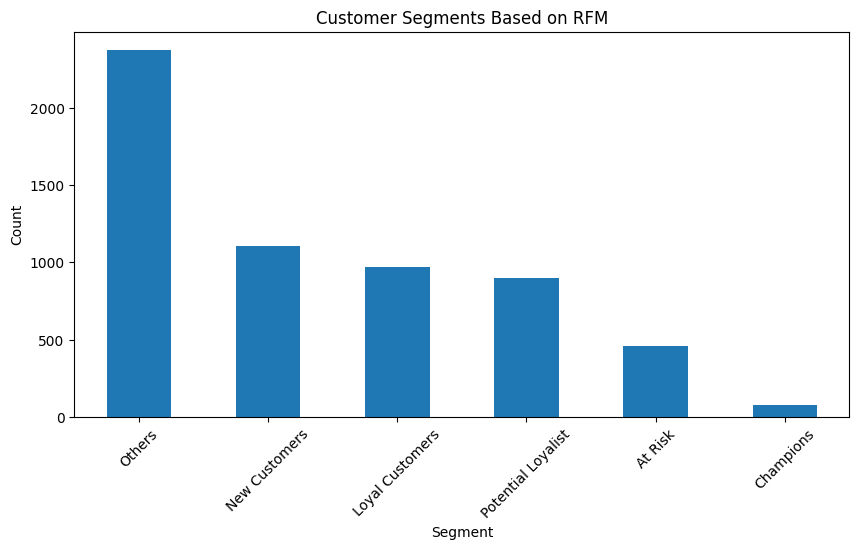

In [19]:
plt.figure(figsize=(10,5))
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Based on RFM")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# Clustering-Based Segmentation (K-Means)

In [20]:
rfm_k = rfm[['Recency','Frequency','Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_k)


Choose Best K (Elbow Method)

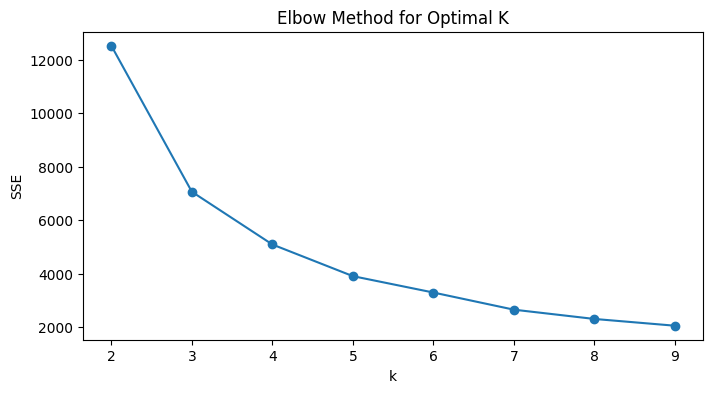

In [21]:
sse = []

for k in range(2,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(2,10), sse, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("k")
plt.ylabel("SSE")
plt.show()


### Fitting K-Means

In [22]:
k = 3  # can update depending on elbow
kmeans = KMeans(n_clusters=k, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM,Segment,Cluster
0,12346.00,529,11,372.86,1,1,3,113,Others,0
1,12347.00,2,8,5633.32,4,1,1,411,New Customers,2
2,12348.00,75,5,2019.40,3,2,2,322,Others,2
3,12349.00,19,4,4428.69,4,2,1,421,New Customers,2
4,12350.00,310,1,334.40,2,4,4,244,Potential Loyalist,0


### PCA (2D Visualization)

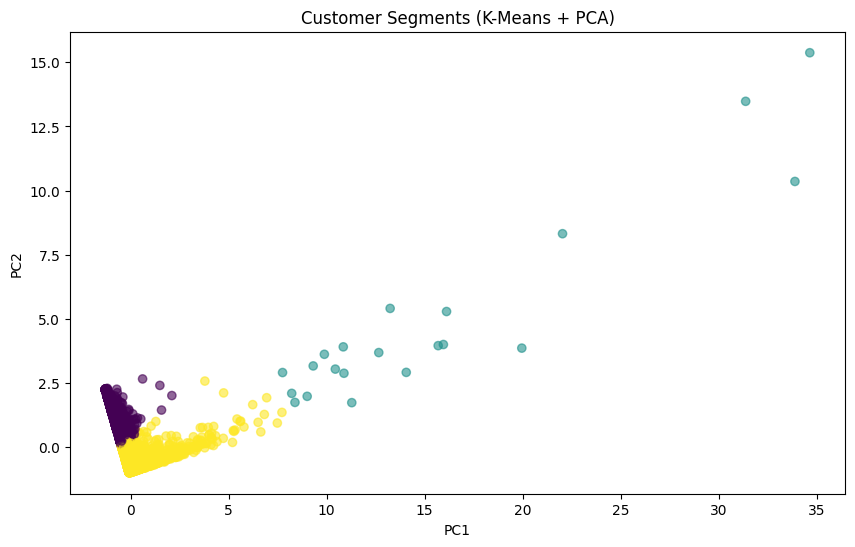

In [23]:
pca = PCA(n_components=2)
pca_points = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10,6))
plt.scatter(pca_points[:,0], pca_points[:,1], c=rfm['Cluster'], alpha=0.6)
plt.title("Customer Segments (K-Means + PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Cluster Profiling

In [24]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()


,Recency,Frequency,Monetary
Cluster,,,
0,461.73,2.21,746.97
1,24.14,149.67,175786.80
2,66.27,7.64,3163.49


### Exporting Segmented RFM Table

In [25]:
rfm.to_csv("rfm_segments.csv", index=False)


# 4. BG/NBD + Gamma-Gamma CLV Modelling

## Part 1 BG/NBD (Beta Geometric / Negative Binomial Distribution)

It uses Recency, Frequency and Customer Age/Tenure (T) to predict how many transactions a customer will make in the future.

BG/NBD (Beta Geometric / Negative Binomial Distribution) assumes:

1. Each customer has their own purchase rate
→ Some buy often, some rarely.

2. Each customer has their own probability of "dropping out"/churning
→ After their last purchase, they may or may not come back.

3. **Purchase rate** varies according to a **Gamma distribution**.
4. **Dropout probability** varies according to a **Beta distribution**.

## Install + Imports

In [26]:
!pip install lifetimes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 9.9 MB/s eta 0:00:00


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix


In [28]:
df = pd.read_csv("/content/clean_online_retail.csv", parse_dates=['InvoiceDate'])


In [29]:
# Filter cancellations
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Lifetimes needs a "calibration_end_date"
end_date = df['InvoiceDate'].max()

lf = df.groupby('Customer ID').agg(
    frequency = ('InvoiceNo', lambda x: x.nunique() - 1),
    recency   = ('InvoiceDate', lambda x: (x.max() - x.min()).days),
    T         = ('InvoiceDate', lambda x: (end_date - x.min()).days),
    monetary_value = ('Order_value', 'mean')
).reset_index()

lf = lf[lf['frequency'] > 0]       # lifetimes requires frequency ≥ 1
lf.head()


,Customer ID,frequency,recency,T,monetary_value
0,12346.00,10,196,725,11.30
1,12347.00,7,402,403,22.27
2,12348.00,4,362,437,39.60
3,12349.00,3,570,588,25.31
6,12352.00,9,356,392,27.67


## Fitting BG/NBD Model (Frequency)

In [30]:
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(lf['frequency'], lf['recency'], lf['T'])


<lifetimes.BetaGeoFitter: fitted with 4253 subjects, a: 0.12, alpha: 77.26, b: 1.14, r: 1.34>

### A: Probability Alive Plot

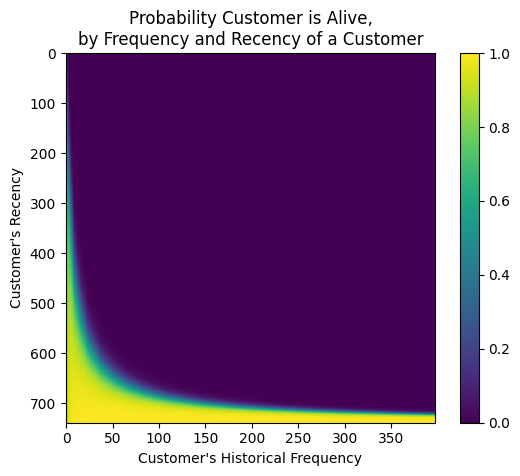

In [31]:
plot_probability_alive_matrix(bgf)
plt.show()


### B: Probability Alive per Customer

In [32]:
lf['prob_alive'] = bgf.conditional_probability_alive(
    lf['frequency'], lf['recency'], lf['T']
)
lf.head()


,Customer ID,frequency,recency,T,monetary_value,prob_alive
0,12346.00,10,196,725,11.30,0.00
1,12347.00,7,402,403,22.27,0.98
2,12348.00,4,362,437,39.60,0.94
3,12349.00,3,570,588,25.31,0.96
6,12352.00,9,356,392,27.67,0.97


## Predicting Future Transactions

### Predict 180 days (6 months):

In [33]:
lf['pred_purchases_6m'] = bgf.predict(
    180, lf['frequency'], lf['recency'], lf['T']
)


### Predicting 365 days (12 months):

In [34]:
lf['pred_purchases_12m'] = bgf.predict(
    365, lf['frequency'], lf['recency'], lf['T']
)


## PART 2 — Gamma-Gamma Model

This model predicts how much a customer will spend per transaction in the future.

Assumptions of GG:

* Monetary value differs across customers

* Monetary value does NOT depend on purchase frequency

* Monetary value follows a Gamma distribution

Inputs to this model:

* Average order value per customer

* Number of transactions

Gamma-Gamma outputs:

→ Expected average future revenue per transaction

Gamma-Gamma predicts monetary value only for customers with > 0 Monetary:

In [35]:
lf_m = lf[lf['monetary_value'] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(lf_m['frequency'], lf_m['monetary_value'])


<lifetimes.GammaGammaFitter: fitted with 4253 subjects, p: 5.33, q: 1.84, v: 4.83>

### Predicting Average Order Value

In [36]:
lf_m['pred_aov'] = ggf.conditional_expected_average_profit(
    lf_m['frequency'], lf_m['monetary_value']
)


## Computing CLV

CLV (over next 6/12 months) = Predicted transactions × Predicted value per transaction

6-month CLV

In [37]:
lf_m['clv_6m'] = ggf.customer_lifetime_value(
    bgf,
    lf_m['frequency'],
    lf_m['recency'],
    lf_m['T'],
    lf_m['monetary_value'],
    time=6,             # months
    discount_rate=0.01  # monthly discount
)


12-Month CLV

In [38]:
lf_m['clv_12m'] = ggf.customer_lifetime_value(
    bgf,
    lf_m['frequency'],
    lf_m['recency'],
    lf_m['T'],
    lf_m['monetary_value'],
    time=12,
    discount_rate=0.01
)


## Rank Customers by CLV

Highest-value customers:

In [39]:
lf_m.sort_values('clv_12m', ascending=False).head(10)


,Customer ID,frequency,recency,T,monetary_value,prob_alive,pred_purchases_6m,pred_purchases_12m,pred_aov,clv_6m,clv_12m
5690,18102.00,144,738,738,575.45,1.00,31.68,63.53,574.85,17590.15,33808.87
5538,17949.00,116,736,737,702.84,1.00,25.59,51.33,701.92,17355.19,33356.42
5048,17450.00,50,429,437,566.97,0.99,17.54,35.01,565.28,9580.47,18327.69
3616,16000.00,2,0,2,1377.08,0.94,6.47,12.47,1278.26,7993.33,14790.91
3946,16333.00,21,302,309,591.71,0.99,10.07,20.02,587.51,5716.28,10893.65
3645,16029.00,105,692,731,298.60,0.82,19.26,38.63,298.20,5549.33,10664.96
581,12931.00,56,717,738,423.61,0.99,12.39,24.85,422.50,5056.82,9718.43
3629,16013.00,83,728,731,261.12,1.00,18.52,37.13,260.68,4662.97,8961.31
2276,14646.00,150,735,736,137.34,1.00,33.06,66.31,137.22,4382.40,8422.96
1330,13694.00,142,731,734,128.84,1.00,31.37,62.92,128.73,3901.58,7498.65


CLV Quantile Segmentation

In [40]:
lf_m['CLV_segment'] = pd.qcut(lf_m['clv_12m'], 4, labels=['Low','Mid','High','Top'])
lf_m['CLV_segment'].value_counts()


,count
CLV_segment,
Low,1064
Mid,1063
High,1063
Top,1063


## CLV Distribution Plot

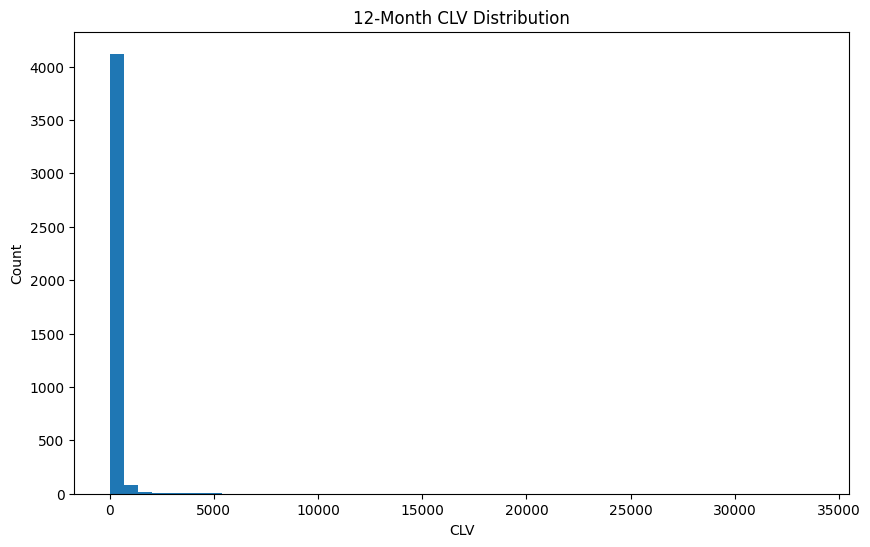

In [41]:
plt.figure(figsize=(10,6))
plt.hist(lf_m['clv_12m'], bins=50)
plt.title("12-Month CLV Distribution")
plt.xlabel("CLV")
plt.ylabel("Count")
plt.show()


## Export Final CLV Table

In [42]:
lf_m.to_csv("customer_clv_probabilistic.csv", index=False)


# 5. Marketing ROI

CAC • ROI • Incrementality • Channel Efficiency • Uplift Simulation

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [44]:
lf = pd.read_csv("/content/customer_clv_probabilistic.csv")
lf.head()


,Customer ID,frequency,recency,T,monetary_value,prob_alive,pred_purchases_6m,pred_purchases_12m,pred_aov,clv_6m,clv_12m,CLV_segment
0,12346.00,10,196,725,11.30,0.00,0.00,0.00,11.60,0.01,0.02,Low
1,12347.00,7,402,403,22.27,0.98,3.01,5.99,22.45,65.21,124.50,Top
2,12348.00,4,362,437,39.60,0.94,1.72,3.42,39.25,65.04,124.17,Top
3,12349.00,3,570,588,25.31,0.96,1.11,2.21,25.57,27.32,52.29,High
4,12352.00,9,356,392,27.67,0.97,3.77,7.51,27.72,100.93,192.69,Top


## Simulate Marketing Channels

Online Retail II has no channel info, so we simulate them realistically.

Assign Customers to Channels

We generate: Paid Search, Paid Social, Email, Organic

In [45]:
np.random.seed(42)

channels = ["Paid Search", "Paid Social", "Email", "Organic"]

lf['AcquisitionChannel'] = np.random.choice(
    channels,
    size=len(lf),
    p=[0.35, 0.25, 0.20, 0.20]  # realistic distribution
)

lf['AcquisitionCost'] = lf['AcquisitionChannel'].map({
    "Paid Search": 12,
    "Paid Social": 8,
    "Email": 2,
    "Organic": 0
})


## CAC and ROI

In [46]:
cac = lf.groupby("AcquisitionChannel")['AcquisitionCost'].mean()
cac


,AcquisitionCost
AcquisitionChannel,
Email,2.00
Organic,0.00
Paid Search,12.00
Paid Social,8.00


## Channel-Level Revenue

In [47]:
channel_revenue = lf.groupby("AcquisitionChannel")['clv_12m'].sum()
channel_revenue


,clv_12m
AcquisitionChannel,
Email,157354.34
Organic,123210.57
Paid Search,244592.04
Paid Social,151679.94


## ROAS & ROI

ROAS = Revenue / Spend
ROI = (Revenue – Spend) / Spend

In [48]:
channel_spend = lf.groupby("AcquisitionChannel")['AcquisitionCost'].sum()

roi_df = pd.DataFrame({
    'Spend': channel_spend,
    'Revenue (12m CLV)': channel_revenue,
})

roi_df['ROAS'] = roi_df['Revenue (12m CLV)'] / roi_df['Spend']
roi_df['ROI'] = (roi_df['Revenue (12m CLV)'] - roi_df['Spend']) / roi_df['Spend']

roi_df


,Spend,Revenue (12m CLV),ROAS,ROI
AcquisitionChannel,,,,
Email,1740,157354.34,90.43,89.43
Organic,0,123210.57,inf,inf
Paid Search,18072,244592.04,13.53,12.53
Paid Social,8248,151679.94,18.39,17.39


## ROI Bar Chart

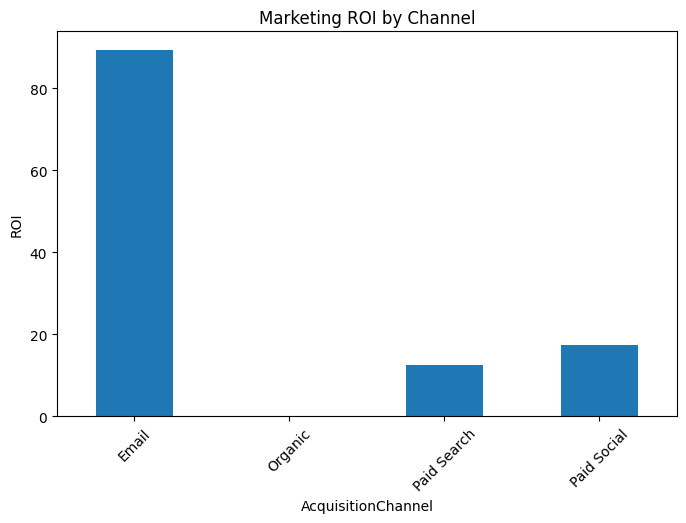

In [49]:
roi_df['ROI'].plot(kind='bar', figsize=(8,5))
plt.title("Marketing ROI by Channel")
plt.ylabel("ROI")
plt.xticks(rotation=45)
plt.show()


## Incrementality & Uplift Testing (A/B)

### Simulating a Paid Social A/B Test

In [50]:
test_group = lf[lf['AcquisitionChannel']=="Paid Social"].sample(frac=0.5, random_state=42)
control_group = lf[lf['AcquisitionChannel']=="Paid Social"].drop(test_group.index)

test_clv = test_group['clv_12m'].mean()
control_clv = control_group['clv_12m'].mean()

incremental_lift = test_clv - control_clv
percent_lift = incremental_lift / control_clv * 100

print("Test CLV:", test_clv)
print("Control CLV:", control_clv)
print("Absolute Lift:", incremental_lift)
print("Percent Lift:", percent_lift, "%")


Test CLV: 128.68919194127096
Control CLV: 165.58508931866817
Absolute Lift: -36.895897377397205
Percent Lift: -22.28213755792415 %


### Uplift Visualization

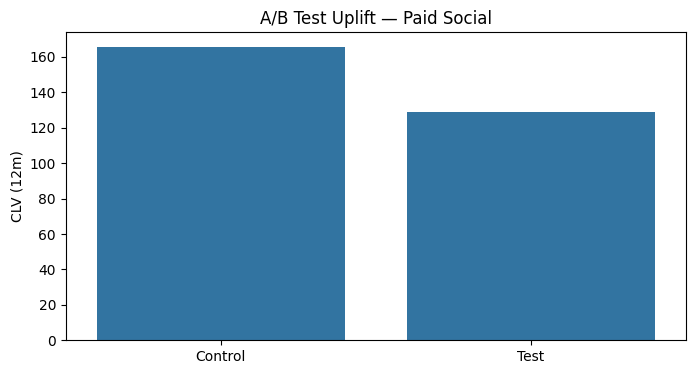

In [51]:
plt.figure(figsize=(8,4))
sns.barplot(x=["Control","Test"], y=[control_clv, test_clv])
plt.title("A/B Test Uplift — Paid Social")
plt.ylabel("CLV (12m)")
plt.show()


## Simple Attribution Model (Heuristic)

If the dataset had touchpoints, you'd use multi-touch attribution.
For now, we do:

Paid Search → High intent

Paid Social → Mid-funnel

Email → Retention

Organic → Brand strength

We weight them:

In [53]:
attribution_weights = {
    "Paid Search": 0.40,
    "Paid Social": 0.25,
    "Email": 0.20,
    "Organic": 0.15
}

lf['AttributedRevenue'] = lf.apply(
    lambda x: x['clv_12m'] * attribution_weights[x['AcquisitionChannel']],
    axis=1
)

lf[['Customer ID','AcquisitionChannel','clv_12m','AttributedRevenue']].head()


,Customer ID,AcquisitionChannel,clv_12m,AttributedRevenue
0,12346.00,Paid Social,0.02,0.01
1,12347.00,Organic,124.50,18.67
2,12348.00,Email,124.17,24.83
3,12349.00,Paid Social,52.29,13.07
4,12352.00,Paid Search,192.69,77.07


### Attribution Revenue by Channel

In [54]:
lf.groupby("AcquisitionChannel")['AttributedRevenue'].sum()


,AttributedRevenue
AcquisitionChannel,
Email,31470.87
Organic,18481.59
Paid Search,97836.82
Paid Social,37919.99


### Attribution vs Spend Plot

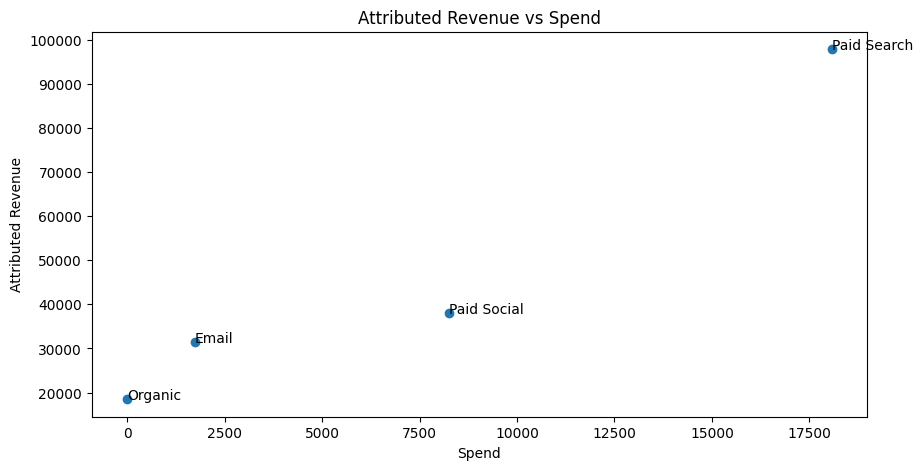

In [55]:
plt.figure(figsize=(10,5))
plt.scatter(channel_spend, lf.groupby('AcquisitionChannel')['AttributedRevenue'].sum())

for ch, spend in channel_spend.items():
    plt.text(spend, lf.groupby('AcquisitionChannel')['AttributedRevenue'].sum()[ch], ch)

plt.xlabel("Spend")
plt.ylabel("Attributed Revenue")
plt.title("Attributed Revenue vs Spend")
plt.show()


## Saving Output

In [56]:
lf.to_csv("marketing_roi_analysis.csv", index=False)


# 6. Dashbaord and Presentation

In [57]:
!pip install --quiet python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.5 MB/s eta 0:00:00


In [2]:
!pip uninstall -y plotly kaleido
!pip install plotly==5.18.0
!pip install kaleido==0.2.1


Found existing installation: plotly 6.1.1
Uninstalling plotly-6.1.1:
  Successfully uninstalled plotly-6.1.1
Found existing installation: kaleido 0.2.1
Uninstalling kaleido-0.2.1:
  Successfully uninstalled kaleido-0.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 58.1 MB/s eta 0:00:00
  Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl (79.9 MB)


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_PARAGRAPH_ALIGNMENT
import os

In [4]:
#pio.kaleido.scope.default_format = "png"
#pio.kaleido.scope.default_width = 1200
#pio.kaleido.scope.default_height = 700

In [5]:
# Load analysis outputs
# Expected files from previous notebooks
clv_path = '/content/customer_clv_probabilistic.csv'
clean_path = '/content/clean_online_retail.csv'
marketing_path = '/content/marketing_roi_analysis.csv'

In [6]:
for p in [clv_path, clean_path, marketing_path]:
    if not os.path.exists(p):
        print(f"Warning: {p} not found in working directory. Please ensure previous notebooks saved outputs.")

In [7]:
# load where available
lf = pd.read_csv(clv_path) if os.path.exists(clv_path) else None
df = pd.read_csv(clean_path, parse_dates=['InvoiceDate']) if os.path.exists(clean_path) else None
mkt = pd.read_csv(marketing_path) if os.path.exists(marketing_path) else None

In [8]:
#Key KPIs
kpis = {}
if lf is not None:
    kpis['Median CLV 12m'] = float(lf['clv_12m'].median())
    kpis['Mean CLV 12m'] = float(lf['clv_12m'].mean())
    kpis['Top 1% CLV'] = float(lf['clv_12m'].quantile(0.99))

if df is not None:
    kpis['Total Revenue'] = float(df['Order_value'].sum())
    kpis['Unique Customers'] = int(df['Customer ID'].nunique())

if mkt is not None:
    # Aggregate channel metrics
    channel_summary = mkt.groupby('AcquisitionChannel').agg(
        customers=('Customer ID','nunique'),
        spend=('AcquisitionCost','sum'),
        revenue=('clv_12m','sum')
    ).reset_index()
    channel_summary['ROAS'] = channel_summary['revenue'] / channel_summary['spend'].replace(0, np.nan)

# print KPIs
print("KPIs summary:")
for k,v in kpis.items():
    print(f"- {k}: {v}")

KPIs summary:
- Median CLV 12m: 46.39422385402271
- Mean CLV 12m: 159.1434029367169
- Top 1% CLV: 1874.017836051623
- Total Revenue: 20481639.048000004
- Unique Customers: 5876


In [9]:
# Plot 1: CLV distribution (histogram + boxplot)
if lf is not None:
    fig_clv = px.histogram(lf, x='clv_12m', nbins=60, title='12-month CLV Distribution', marginal='box')
    fig_clv.update_layout(xaxis_title='CLV (12 months)', yaxis_title='Count')
    fig_clv.show()
    fig_clv.write_image('/content/clv_distribution.png',engine="kaleido")

In [10]:
# Plot 2: Top customers cumulative revenue
if lf is not None:
    # Take top 100 customers by CLV
    top = lf.sort_values('clv_12m', ascending=False).head(100).copy()
    top = top.reset_index(drop=True)

    # Add rank column for X-axis
    top['rank'] = top.index + 1

    # Compute cumulative revenue
    top['cum_revenue'] = top['clv_12m'].cumsum()

    # Plot
    fig_top = px.line(
        top,
        x='rank',
        y='cum_revenue',
        title='Cumulative CLV of Top 100 Customers',
        markers=True
    )
    fig_top.update_layout(
        xaxis_title='Customer Rank (by CLV)',
        yaxis_title='Cumulative CLV',
        template='plotly_white'
    )
    fig_top.update_traces(
        hovertemplate="Rank: %{x}<br>Cumulative CLV: %{y:$,.2f}"
    )
    fig_top.show()

    # Export to PNG (make sure kaleido installed)
    fig_top.write_image('/content/top100_cumulative_clv.png')


In [49]:
# Plot 3: Cohort retention heatmap (if cohort file exists)
# If cohort retention matrix was produced earlier as 'cohort_retention.csv', load it. Otherwise compute a quick cohort heatmap from df
cohort_img_path = '/content/cohort_retention_heatmap.png'
if os.path.exists('cohort_retention.csv'):
    cohort = pd.read_csv('cohort_retention.csv', index_col=0)
    fig_cohort = px.imshow(cohort.values, labels=dict(x='Months Since Cohort', y='Cohort Month', color='Retention'),
                           x=cohort.columns, y=cohort.index, title='Cohort Retention Heatmap')
    fig_cohort.show()
    fig_cohort.write_image(cohort_img_path)
elif df is not None:
    # quick cohort computation (lightweight)
    df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
    df['CohortMonth'] = df.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
    df['CohortIndex'] = (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 + (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month) + 1
    cohort_data = df.groupby(['CohortMonth','CohortIndex'])['Customer ID'].nunique().reset_index()
    cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID').fillna(0)
    cohort_size = cohort_pivot.iloc[:,0]
    retention = (cohort_pivot.divide(cohort_size, axis=0)).round(3)
    fig_cohort = px.imshow(retention.values, labels=dict(x='Months Since Cohort', y='Cohort Month', color='Retention'),
                           x=retention.columns.astype(str), y=retention.index.astype(str), title='Cohort Retention Heatmap')
    fig_cohort.show()
    fig_cohort.write_image(cohort_img_path)
else:
    print('No cohort data available to plot retention heatmap')


In [50]:
#Plot 4: Channel performance (bar chart)
if mkt is not None:
    fig_chan = px.bar(channel_summary, x='AcquisitionChannel', y=['customers','spend','revenue'], barmode='group',
                     title='Channel Performance: Customers, Spend, Revenue')
    fig_chan.show()
    fig_chan.write_image('channel_performance.png')

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [51]:
# Plot 5: CLV by Segment (if segmentation exists)
if os.path.exists('rfm_segments.csv') and lf is not None:
    rfm = pd.read_csv('rfm_segments.csv')
    merged = lf.merge(rfm[['Customer ID','Segment']], on='Customer ID', how='left')
    seg_summary = merged.groupby('Segment')['clv_12m'].agg(['mean','median','count']).reset_index()
    fig_seg = px.bar(seg_summary, x='Segment', y='median', title='Median CLV by RFM Segment')
    fig_seg.show()
    fig_seg.write_image('/content/clv_by_segment.png')

In [56]:
# Export PNGs to presentation folder
os.makedirs('presentation_assets', exist_ok=True)
for img in ['/content/clv_distribution.png','/content/top100_cumulative_clv.png', cohort_img_path, '/content/channel_performance.png','/content/clv_by_segment.png']:
    if os.path.exists(img):
        dst = os.path.join('presentation_assets', os.path.basename(img))
        os.replace(img, dst) if not os.path.exists(dst) else None

print('Saved available images to presentation_assets/')


Saved available images to presentation_assets/


In [17]:
# Build PowerPoint
prs = Presentation()
# Title slide
slide_layout = prs.slide_layouts[0]
slide = prs.slides.add_slide(slide_layout)
title = slide.shapes.title
subtitle = slide.placeholders[1]
title.text = "LTV, Retention & Marketing ROI — Executive Summary"
subtitle.text = "Generated by analysis pipeline"

In [18]:
# KPI slide
slide_layout = prs.slide_layouts[5]
slide = prs.slides.add_slide(slide_layout)
shapes = slide.shapes
title_shape = shapes.title
title_shape.text = 'Key KPIs'

from pptx.util import Inches

# Add textbox manually
left = Inches(1)
top = Inches(2)
width = Inches(8)
height = Inches(4)
textbox = slide.shapes.add_textbox(left, top, width, height)
tf = textbox.text_frame

for k, v in kpis.items():
    p = tf.add_paragraph()
    p.text = f"{k}: {v}"
    p.level =1


In [19]:
# Add images slides
def add_image_slide(prs, title_text, image_path):
    if not os.path.exists(image_path):
        return
    slide_layout = prs.slide_layouts[6]
    slide = prs.slides.add_slide(slide_layout)
    title_shape = slide.shapes.title if slide.shapes.title else None
    try:
        slide.shapes.title.text = title_text
    except Exception:
        pass
    left = Inches(0.5)
    top = Inches(1.2)
    pic = slide.shapes.add_picture(image_path, left, top, width=Inches(9))

# attach images if exist
assets_folder = 'presentation_assets'
assets = []

if os.path.exists(assets_folder):
    # only take files, ignore directories
    assets = [f for f in os.listdir(assets_folder)
              if os.path.isfile(os.path.join(assets_folder, f))]

for img in assets:
    add_image_slide(prs,
                    os.path.splitext(img)[0].replace('_',' ').title(),
                    os.path.join(assets_folder, img))

pptx_path = '/content/LTV_Retention_Marketing_Report.pptx'
prs.save(pptx_path)
print(f'PowerPoint saved to {pptx_path}')

PowerPoint saved to /content/LTV_Retention_Marketing_Report.pptx


In [20]:
# Provide download link (Colab-friendly)
from IPython.display import FileLink, display
if os.path.exists(pptx_path):
    display(FileLink(pptx_path))

/content/LTV_Retention_Marketing_Report.pptx

In [21]:
# Next steps & tips
print('Dashboard & presentation generation complete.')
print('- If some images are missing, run earlier notebooks to generate required files: customer_clv_probabilistic.csv, marketing_roi_analysis.csv, rfm_segments.csv, cohort_retention.csv')
print('- You can edit the PPTX slide order or text manually in PowerPoint/Google Slides.')


Dashboard & presentation generation complete.
- If some images are missing, run earlier notebooks to generate required files: customer_clv_probabilistic.csv, marketing_roi_analysis.csv, rfm_segments.csv, cohort_retention.csv
- You can edit the PPTX slide order or text manually in PowerPoint/Google Slides.
